# Rezonans stochastyczny w potencjale bistabilnym

Ten notebook wizualizuje zjawisko rezonansu stochastycznego z wykładu 10: cząstkę lub układ dwustanowy w potencjale bistabilnym, którego bariera jest okresowo modulowana słabym sygnałem. Szum o natężeniu `D` ułatwia przejścia między studniami. Dla odpowiedniego poziomu szumu przejścia synchronizują się z sygnałem okresowym, co daje wyraźny pik w widmie mocy.

Zakres projektu:

- pokazanie okresowej zmiany wysokości bariery potencjału,
- wykresy czasowe prawdopodobieństwa `n_+(t)` oraz losowego sygnału wyjściowego `y(t)`,
- widmo mocy z pikiem przy częstości wymuszenia,
- bez liczenia stosunku sygnału do szumu (SNR).

Model bazuje na przybliżeniu dwustanowym i równaniu Master omawianym na wykładzie. Szybkości przejść są opisane wzorem Kramersa.

## Jak czytać ten notebook

Notebook jest napisany tak, aby prowadzić od intuicji do wyników numerycznych:

1. Najpierw pokazujemy **potencjał bistabilny**, czyli układ z dwiema studniami i barierą między nimi.
2. Następnie opisujemy układ jako **model dwustanowy**, w którym liczy się tylko to, czy cząstka jest w lewej, czy prawej studni.
3. Potem pokazujemy **odpowiedź na wymuszenie okresowe** oraz sygnał wyjściowy `y(t)=±1`.
4. Kolejna część symuluje pełniejszą trajektorię `x(t)` przez **równanie Langevina**.
5. Na końcu analizujemy **widmo mocy** i wyznaczamy optymalny poziom szumu `D`.

Najważniejsza idea jest paradoksalna: w tym nieliniowym układzie szum nie tylko przeszkadza. Dobrze dobrany szum pomaga układowi reagować na słaby sygnał okresowy.

## Słownik podstawowych pojęć

- **Potencjał bistabilny**: funkcja energii z dwoma minimami. Minima odpowiadają dwóm stabilnym stanom układu, nazywanym tutaj lewą i prawą studnią.
- **Bariera potencjału**: maksimum energii między studniami. Im wyższa bariera, tym trudniej cząstce przejść do drugiej studni.
- **Wymuszenie okresowe**: słaby sygnał sinusoidalny, który okresowo przechyla potencjał i zmienia wysokości barier.
- **Szum stochastyczny**: losowe zaburzenie o natężeniu `D`. W symulacji odpowiada za przypadkowe ruchy i przejścia cząstki.
- **Rezonans stochastyczny**: zjawisko, w którym pewien niezerowy poziom szumu maksymalizuje odpowiedź układu na słaby sygnał okresowy.
- **Sygnał wyjściowy dwustanowy**: uproszczony opis `y(t)=+1` dla prawej studni i `y(t)=-1` dla lewej studni.
- **Widmo mocy**: informacja, jakie częstości występują w sygnale. Pik przy częstości wymuszenia oznacza, że układ odpowiada w rytmie sygnału wejściowego.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

FIG_DIR = Path("figury")
FIG_DIR.mkdir(exist_ok=True)


@dataclass(frozen=True)
class Params:
    """Parametry bezwymiarowego modelu rezonansu stochastycznego."""

    barrier0: float = 1.0          # U0: wysokość bariery bez modulacji
    eta0: float = 0.35             # amplituda modulacji bariery, jako część U0
    D: float = 0.28                # natężenie szumu
    omega: float = 0.15            # częstość kątowa sygnału okresowego
    prefactor: float = 1.0         # prefaktor Kramersa
    periods: int = 140             # liczba okresów do symulacji
    transient_periods: int = 20    # okresy odrzucane przed analizą widma
    steps_per_period: int = 320    # rozdzielczość czasowa
    seed: int = 2026

    @property
    def amplitude(self) -> float:
        return self.eta0 * self.barrier0

    @property
    def period(self) -> float:
        return 2 * np.pi / self.omega

    @property
    def dt(self) -> float:
        return self.period / self.steps_per_period


params = Params()


def drive(t, p=params):
    """Słaby sygnał okresowy modulujący wysokości barier."""
    return np.cos(p.omega * np.asarray(t))


def V_s(x, t, p=params):
    """Potencjał bistabilny z okresowym przechyleniem.

    Część (x^2 - 1)^2 daje dwie studnie w pobliżu x = -1 i x = +1.
    Człon liniowy -A x cos(omega t) okresowo obniża raz jedną, raz drugą barierę.
    """
    x = np.asarray(x)
    return p.barrier0 * (x**2 - 1)**2 - p.amplitude * x * drive(t, p)


def barrier_heights(t, p=params):
    """Bariery przejść: lewa -> prawa oraz prawa -> lewa.

    U_siodla = V(0,t) = U0. Dla minimów około x=-1 i x=+1 otrzymujemy
    okresowo zmienne bariery U0 ∓ A cos(omega t).
    """
    modulation = p.amplitude * drive(t, p)
    left_to_right = p.barrier0 - modulation
    right_to_left = p.barrier0 + modulation
    return left_to_right, right_to_left


def transition_rates(t, p=params):
    """Szybkości Kramersa dla przejść między studniami."""
    delta_lr, delta_rl = barrier_heights(t, p)
    w_lr = p.prefactor * np.exp(-delta_lr / p.D)  # -1 -> +1
    w_rl = p.prefactor * np.exp(-delta_rl / p.D)  # +1 -> -1
    return w_lr, w_rl


def time_grid(p=params):
    n = p.periods * p.steps_per_period + 1
    return np.linspace(0, p.periods * p.period, n)

## Potencjał i okresowa zmiana bariery

Poniżej widać ten sam potencjał w czterech fazach wymuszenia. Gdy sygnał okresowy przechyla potencjał, jedna bariera maleje, a druga rośnie. To właśnie okresowe obniżanie barier umożliwia synchronizację przejść wywołanych szumem.

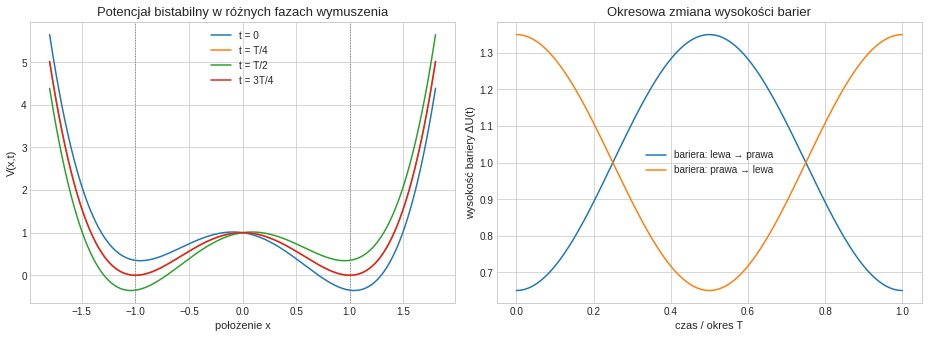

In [2]:
x = np.linspace(-1.8, 1.8, 500)
phase_times = np.array([0, 0.25, 0.5, 0.75]) * params.period
phase_labels = ["0", "T/4", "T/2", "3T/4"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for t_phase, label in zip(phase_times, phase_labels):
    axes[0].plot(x, V_s(x, t_phase), label=f"t = {label}")
axes[0].axvline(-1, color="0.5", lw=1, ls=":")
axes[0].axvline(1, color="0.5", lw=1, ls=":")
axes[0].set_title("Potencjał bistabilny w różnych fazach wymuszenia")
axes[0].set_xlabel("położenie x")
axes[0].set_ylabel("V(x,t)")
axes[0].legend()

one_period = np.linspace(0, params.period, 800)
delta_lr, delta_rl = barrier_heights(one_period)
axes[1].plot(one_period / params.period, delta_lr, label="bariera: lewa → prawa")
axes[1].plot(one_period / params.period, delta_rl, label="bariera: prawa → lewa")
axes[1].set_title("Okresowa zmiana wysokości barier")
axes[1].set_xlabel("czas / okres T")
axes[1].set_ylabel("wysokość bariery ΔU(t)")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "01_potencjal_i_bariery.png", dpi=160)
plt.show()

### Intuicja bariery potencjału

Potencjał można wyobrazić sobie jak krajobraz z dwiema dolinami oddzielonymi wzgórzem. Cząstka najchętniej przebywa w dolinach, bo tam energia jest najmniejsza. Żeby przejść do drugiej doliny, musi pokonać wzgórze, czyli barierę potencjału.

Słaby sygnał okresowy nie usuwa bariery całkowicie. On tylko okresowo przechyla krajobraz: raz łatwiej jest przejść z lewej studni do prawej, a pół okresu później łatwiej jest przejść z prawej do lewej. Gdy do tego dołożymy odpowiednio dobrany szum, losowe przeskoki zaczynają pojawiać się w rytmie sygnału okresowego.

## Równanie Master i losowy sygnał wyjściowy

W przybliżeniu dwustanowym opisujemy tylko to, czy układ jest w lewej (`-1`) czy prawej (`+1`) studni. Szybkości przejść są zadane wzorem Kramersa: im mniejsza chwilowa bariera i im większy szum `D`, tym większe prawdopodobieństwo przejścia.

Dla prawdopodobieństwa bycia w prawej studni rozwiązujemy równanie Master:

$
\dot n_+(t)=W_{-\to +}(t)(1-n_+(t))-W_{+\to -}(t)n_+(t).
$

Oprócz średniej odpowiedzi `n_+(t)` generujemy też losową trajektorię `y(t)=±1`, żeby widmo zawierało zarówno pik okresowy, jak i tło szumowe.

/tmp/ipykernel_44043/2487409226.py:70: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_44043/2487409226.py:71: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.savefig(FIG_DIR / "02_master_i_realizacja.png", dpi=160)


/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


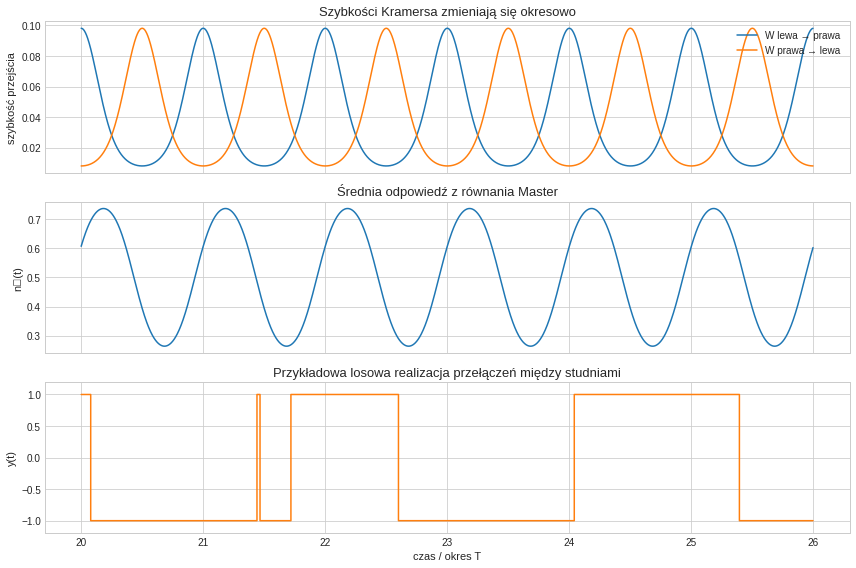

In [3]:
def solve_master_equation(p=params):
    t_eval = time_grid(p)

    def rhs(t, n):
        w_lr, w_rl = transition_rates(t, p)
        n_plus = n[0]
        return [w_lr * (1 - n_plus) - w_rl * n_plus]

    solution = solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        y0=[0.5],
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
    )
    if not solution.success:
        raise RuntimeError(solution.message)
    return solution.t, solution.y[0]


def simulate_two_state_process(p=params, n_realizations=1):
    """Symulacja dyskretna procesu przełączeń z czasowo zależnymi stopami Kramersa."""
    rng = np.random.default_rng(p.seed)
    t = time_grid(p)
    y = np.empty((n_realizations, len(t)), dtype=float)

    for r in range(n_realizations):
        state = rng.choice([-1.0, 1.0])
        y[r, 0] = state
        for i in range(1, len(t)):
            w_lr, w_rl = transition_rates(t[i - 1], p)
            rate = w_lr if state < 0 else w_rl
            switch_probability = 1 - np.exp(-rate * p.dt)
            if rng.random() < switch_probability:
                state *= -1
            y[r, i] = state

    return t, y[0] if n_realizations == 1 else y


t, n_plus = solve_master_equation(params)
y_mean = 2 * n_plus - 1
t, y_sample = simulate_two_state_process(params, n_realizations=1)

w_lr, w_rl = transition_rates(t, params)

plot_start = params.transient_periods * params.steps_per_period
plot_stop = plot_start + 6 * params.steps_per_period
sl = slice(plot_start, plot_stop)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t[sl] / params.period, w_lr[sl], label="W lewa → prawa")
axes[0].plot(t[sl] / params.period, w_rl[sl], label="W prawa → lewa")
axes[0].set_ylabel("szybkość przejścia")
axes[0].set_title("Szybkości Kramersa zmieniają się okresowo")
axes[0].legend(loc="upper right")

axes[1].plot(t[sl] / params.period, n_plus[sl], color="tab:blue")
axes[1].set_ylabel("n₊(t)")
axes[1].set_title("Średnia odpowiedź z równania Master")

axes[2].step(t[sl] / params.period, y_sample[sl], where="post", color="tab:orange")
axes[2].set_ylabel("y(t)")
axes[2].set_xlabel("czas / okres T")
axes[2].set_title("Przykładowa losowa realizacja przełączeń między studniami")
axes[2].set_ylim(-1.2, 1.2)

fig.tight_layout()
fig.savefig(FIG_DIR / "02_master_i_realizacja.png", dpi=160)
plt.show()

### Dlaczego można zastąpić cząstkę modelem dwustanowym?

Pełna trajektoria cząstki zawiera wiele szybkich, losowych ruchów wewnątrz jednej studni. W rezonansie stochastycznym najważniejsze jest jednak to, **kiedy cząstka przechodzi z jednej studni do drugiej**. Dlatego często upraszcza się układ do dwóch stanów: lewa studnia `-1` i prawa studnia `+1`.

Równanie Master opisuje prawdopodobieństwo przebywania w prawej studni. Zamiast śledzić każde drgnięcie cząstki, pytamy: jaka jest szansa, że układ jest po prawej stronie? Szybkości przejść `W` zależą od chwilowej wysokości bariery i od szumu `D`, dlatego model nadal zachowuje najważniejszą fizykę problemu.

## Wymuszenie okresowe a odpowiedź układu

Poniższe wykresy pokazują bezpośredni związek między sygnałem wejściowym `s(t)=cos(ωt)` a odpowiedzią układu. Są to wykresy analogiczne do tych po prawej stronie pierwszego slajdu: najpierw widzimy wymuszenie okresowe, potem gładką odpowiedź średnią układu, a następnie dwustanowy sygnał wyjściowy.

Sygnał wyjściowy dwustanowy podkreśla momenty przejścia cząstki pomiędzy dwiema studniami potencjału i ułatwia ocenę synchronizacji z sygnałem wejściowym. Pionowe linie na dolnym wykresie oznaczają chwile, w których zaszło przejście między studniami.

/tmp/ipykernel_44043/4258277530.py:52: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_44043/4258277530.py:53: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.savefig(FIG_DIR / "03_wymuszenie_i_odpowiedz.png", dpi=170)


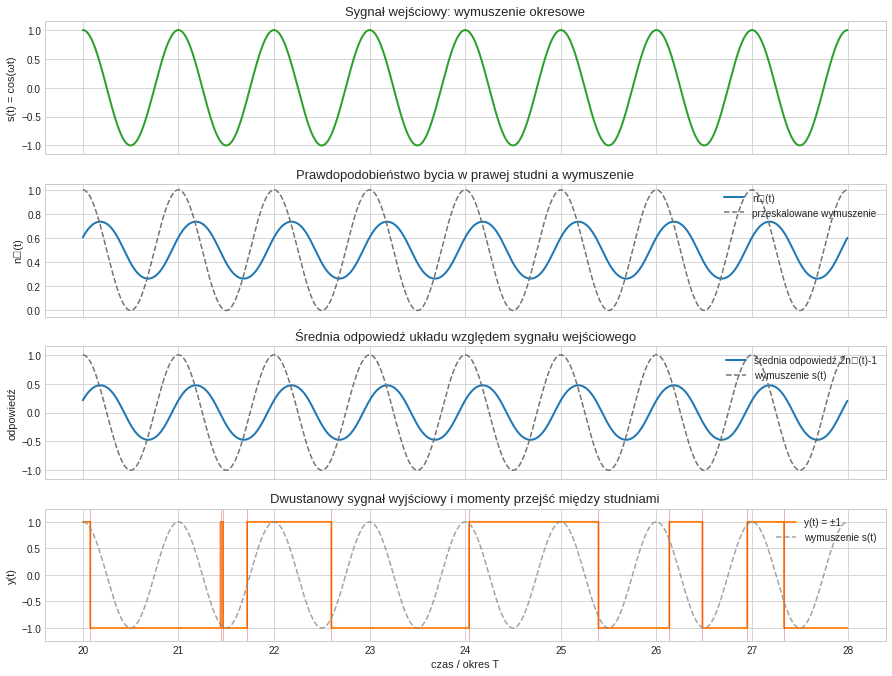

/tmp/ipykernel_44043/4258277530.py:65: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_44043/4258277530.py:66: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.savefig(FIG_DIR / "04_zaleznosc_odpowiedzi_od_wymuszenia.png", dpi=170)


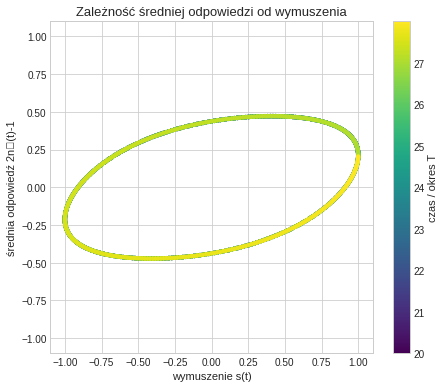

In [4]:
comparison_start = params.transient_periods * params.steps_per_period
comparison_stop = comparison_start + 8 * params.steps_per_period
comparison_sl = slice(comparison_start, comparison_stop)

comparison_time = t[comparison_sl] / params.period
input_signal = drive(t, params)
input_window = input_signal[comparison_sl]
y_mean_window = y_mean[comparison_sl]
n_plus_window = n_plus[comparison_sl]
y_window = y_sample[comparison_sl]

transition_local_idx = np.flatnonzero(np.diff(y_window) != 0) + 1
transition_times = comparison_time[transition_local_idx]

fig, axes = plt.subplots(4, 1, figsize=(12.5, 9.5), sharex=True)

axes[0].plot(comparison_time, input_window, color="tab:green", lw=2)
axes[0].set_title("Sygnał wejściowy: wymuszenie okresowe")
axes[0].set_ylabel("s(t) = cos(ωt)")
axes[0].set_ylim(-1.15, 1.15)

axes[1].plot(comparison_time, n_plus_window, color="tab:blue", lw=2, label="n₊(t)")
axes[1].plot(
    comparison_time,
    0.5 * (input_window + 1),
    color="0.45",
    ls="--",
    label="przeskalowane wymuszenie",
)
axes[1].set_title("Prawdopodobieństwo bycia w prawej studni a wymuszenie")
axes[1].set_ylabel("n₊(t)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="upper right")

axes[2].plot(comparison_time, y_mean_window, color="tab:blue", lw=2, label="średnia odpowiedź 2n₊(t)-1")
axes[2].plot(comparison_time, input_window, color="0.45", ls="--", label="wymuszenie s(t)")
axes[2].set_title("Średnia odpowiedź układu względem sygnału wejściowego")
axes[2].set_ylabel("odpowiedź")
axes[2].set_ylim(-1.15, 1.15)
axes[2].legend(loc="upper right")

axes[3].step(comparison_time, y_window, where="post", color="tab:orange", lw=1.8, label="y(t) = ±1")
for transition_time in transition_times:
    axes[3].axvline(transition_time, color="tab:red", lw=0.8, alpha=0.45)
axes[3].plot(comparison_time, input_window, color="0.55", ls="--", alpha=0.8, label="wymuszenie s(t)")
axes[3].set_title("Dwustanowy sygnał wyjściowy i momenty przejść między studniami")
axes[3].set_ylabel("y(t)")
axes[3].set_xlabel("czas / okres T")
axes[3].set_ylim(-1.25, 1.25)
axes[3].legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_wymuszenie_i_odpowiedz.png", dpi=170)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
scatter = ax.scatter(input_window, y_mean_window, c=comparison_time, s=12, cmap="viridis")
ax.set_title("Zależność średniej odpowiedzi od wymuszenia")
ax.set_xlabel("wymuszenie s(t)")
ax.set_ylabel("średnia odpowiedź 2n₊(t)-1")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("czas / okres T")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_zaleznosc_odpowiedzi_od_wymuszenia.png", dpi=170)
plt.show()

### Co pokazują wykresy zależności wejście-wyjście?

Wymuszenie okresowe jest słabe, więc samo w sobie nie powinno deterministycznie przerzucać cząstki z jednej studni do drugiej. Jego rola polega na okresowym obniżaniu jednej bariery i podwyższaniu drugiej. Szum dostarcza losowych „kopnięć”, a wymuszenie decyduje, kiedy przejście jest bardziej prawdopodobne.

Dlatego porównujemy trzy sygnały: wejście `s(t)`, gładką średnią odpowiedź `2n_+(t)-1` oraz dwustanowy sygnał `y(t)`. Jeżeli przejścia w `y(t)` występują częściej w określonych fazach sygnału wejściowego, oznacza to synchronizację typową dla rezonansu stochastycznego.

## Symulacja trajektorii cząstki: równanie Langevina

W poprzednich sekcjach układ był opisany w przybliżeniu dwustanowym, przez prawdopodobieństwo `n_+(t)`. Tutaj symulujemy już samą trajektorię cząstki `x(t)` w potencjale bistabilnym. Jest to wersja bliższa intuicyjnemu obrazowi ze slajdu: cząstka porusza się w lewej lub prawej studni, czasem przeskakując przez barierę pod wpływem szumu.

Używamy równania Langevina w postaci bezwymiarowej:

$
dx = \left(x - x^3 + A\sin(\omega t)\right)dt + \sqrt{2D}\,dW_t.
$

Człon `x - x^3` odpowiada sile od podwójnej studni potencjału, `A sin(ωt)` jest słabym wymuszeniem okresowym, a `sqrt(2D)dW_t` reprezentuje biały szum stochastyczny. Równanie całkujemy metodą Eulera-Maruyamy.

Z trajektorii `x(t)` tworzymy sygnał dwustanowy:

$
y(t)=\begin{cases}
+1, & x(t) \ge 0,\\
-1, & x(t) < 0.
\end{cases}
$

Taki sygnał wyjściowy podkreśla momenty przejścia cząstki pomiędzy dwiema studniami potencjału i ułatwia ocenę synchronizacji z sygnałem wejściowym.

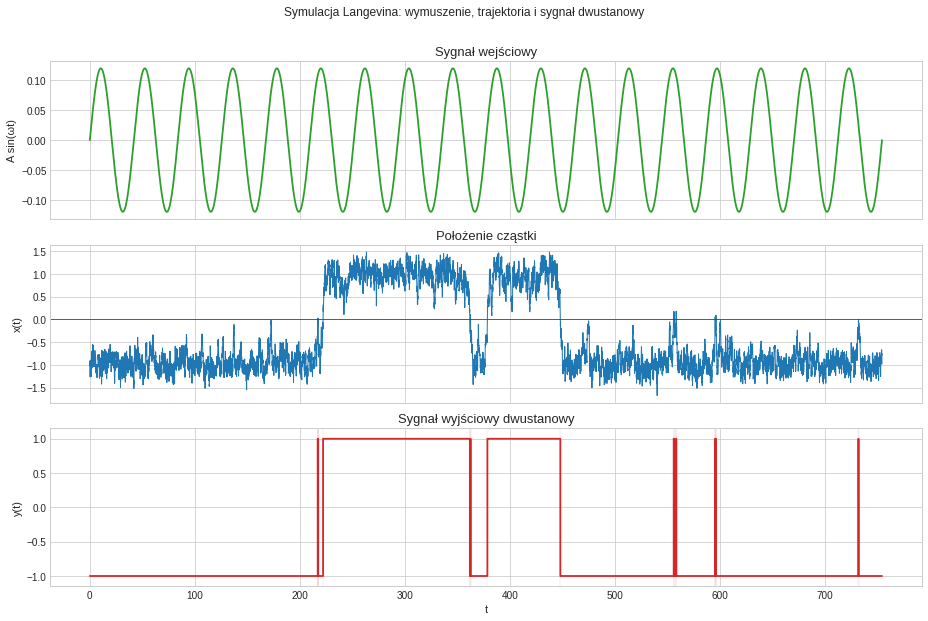

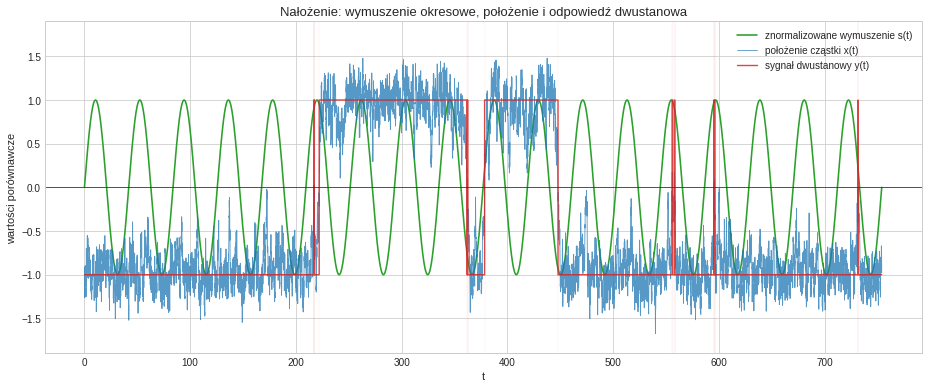

Liczba przejść między studniami w symulacji: 20
Czas symulacji: 754.0, czyli 18 okresów wymuszenia


In [5]:
def simulate_langevin_trajectory(
    p=params,
    forcing_amplitude=0.12,
    noise_intensity=0.07,
    periods=18,
    steps_per_period=700,
    x0=-1.0,
    seed=2028,
):
    """Euler-Maruyama dla cząstki w potencjale bistabilnym.

    Model: dx = (x - x^3 + A sin(omega t)) dt + sqrt(2D) dW.
    """
    rng = np.random.default_rng(seed)
    t_end = periods * p.period
    dt = p.period / steps_per_period
    n_steps = int(t_end / dt) + 1
    t_sde = np.linspace(0, t_end, n_steps)
    x_sde = np.empty(n_steps)
    x_sde[0] = x0

    for i in range(n_steps - 1):
        forcing = forcing_amplitude * np.sin(p.omega * t_sde[i])
        drift = x_sde[i] - x_sde[i] ** 3 + forcing
        diffusion = np.sqrt(2 * noise_intensity * dt) * rng.normal()
        x_sde[i + 1] = x_sde[i] + drift * dt + diffusion

    input_sde = forcing_amplitude * np.sin(p.omega * t_sde)
    y_sde = np.where(x_sde >= 0, 1.0, -1.0)
    return t_sde, input_sde, x_sde, y_sde


t_sde, input_sde, x_sde, y_sde = simulate_langevin_trajectory()
transition_idx = np.flatnonzero(np.diff(y_sde) != 0) + 1
transition_t = t_sde[transition_idx]

fig, axes = plt.subplots(3, 1, figsize=(13, 8.5), sharex=True)

axes[0].plot(t_sde, input_sde, color="tab:green", lw=1.8)
axes[0].set_title("Sygnał wejściowy")
axes[0].set_ylabel("A sin(ωt)")

axes[1].plot(t_sde, x_sde, color="tab:blue", lw=1.0)
axes[1].axhline(0, color="0.25", lw=0.8)
axes[1].set_title("Położenie cząstki")
axes[1].set_ylabel("x(t)")

axes[2].step(t_sde, y_sde, where="post", color="tab:red", lw=1.8)
for jump_t in transition_t:
    axes[2].axvline(jump_t, color="tab:red", lw=0.45, alpha=0.20)
axes[2].set_title("Sygnał wyjściowy dwustanowy")
axes[2].set_ylabel("y(t)")
axes[2].set_xlabel("t")
axes[2].set_ylim(-1.15, 1.15)

fig.suptitle("Symulacja Langevina: wymuszenie, trajektoria i sygnał dwustanowy", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_langevin_trzy_wykresy.png", dpi=170, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(13, 5.5))
normalized_input = input_sde / np.max(np.abs(input_sde))
ax.plot(t_sde, normalized_input, color="tab:green", lw=1.6, label="znormalizowane wymuszenie s(t)")
ax.plot(t_sde, x_sde, color="tab:blue", lw=0.85, alpha=0.75, label="położenie cząstki x(t)")
ax.step(t_sde, y_sde, where="post", color="tab:red", lw=1.4, alpha=0.85, label="sygnał dwustanowy y(t)")
for jump_t in transition_t:
    ax.axvline(jump_t, color="tab:red", lw=0.35, alpha=0.12)
ax.axhline(0, color="0.2", lw=0.8)
ax.set_title("Nałożenie: wymuszenie okresowe, położenie i odpowiedź dwustanowa")
ax.set_xlabel("t")
ax.set_ylabel("wartości porównawcze")
ax.set_ylim(-1.9, 1.9)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_langevin_nalozone_wykresy.png", dpi=170)
plt.show()

print(f"Liczba przejść między studniami w symulacji: {len(transition_t)}")
print(f"Czas symulacji: {t_sde[-1]:.1f}, czyli {t_sde[-1] / params.period:.0f} okresów wymuszenia")

### Jak interpretować wykresy Langevina?

W tej symulacji wykres `x(t)` pokazuje położenie cząstki. Wartości ujemne oznaczają lewą studnię potencjału, a wartości dodatnie prawą studnię. Linia `x=0` jest umowną granicą między studniami, blisko maksimum bariery.

Sygnał dwustanowy `y(t)` jest uproszczeniem trajektorii: nie interesuje nas dokładne drganie cząstki w studni, tylko to, po której stronie bariery się znajduje. Dzięki temu łatwo zobaczyć same przejścia między studniami. To właśnie przejścia, a nie drobne fluktuacje `x(t)`, są najważniejsze dla oceny rezonansu stochastycznego.

## Autokorelacja i widmo mocy

Z twierdzenia Wienera-Chinczyna widmo mocy jest transformatą Fouriera funkcji autokorelacji. Numerycznie korzystamy z równoważnej postaci periodogramu: po odrzuceniu pierwszych okresów (`transient`) liczymy FFT sygnału `y(t)`. Aby tło szumowe było stabilne, widmo uśredniamy po wielu losowych realizacjach procesu przełączeń.

Na wykresie pionowa linia oznacza częstość wymuszenia `ω`. Oczekiwany efekt to pik widma właśnie w tym miejscu.

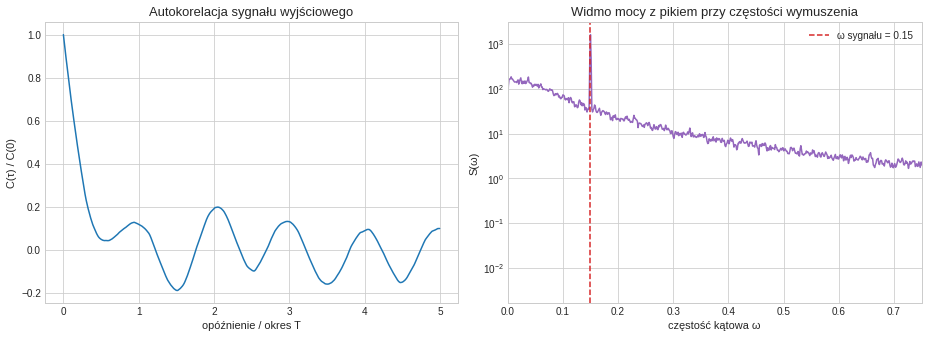

In [6]:
def autocorrelation_fft(signal):
    """Autokorelacja liczona przez FFT, dla nieujemnych opóźnień."""
    x = np.asarray(signal, dtype=float)
    x = x - x.mean()
    n = len(x)
    fft_values = np.fft.rfft(x, n=2 * n)
    corr = np.fft.irfft(fft_values * np.conj(fft_values), n=2 * n)[:n]
    corr /= np.arange(n, 0, -1)
    return corr / corr[0]


def power_spectrum(signal, dt):
    """Widmo mocy w funkcji częstości kątowej omega."""
    x = np.asarray(signal, dtype=float)
    x = x - x.mean()
    window = np.hanning(len(x))
    xw = x * window
    spectrum = np.abs(np.fft.rfft(xw)) ** 2 / np.sum(window**2)
    omega = 2 * np.pi * np.fft.rfftfreq(len(x), d=dt)
    return omega, spectrum


def averaged_spectrum(p=params, n_realizations=80):
    t, samples = simulate_two_state_process(p, n_realizations=n_realizations)
    samples = samples[:, p.transient_periods * p.steps_per_period :]
    spectra = []
    for sample in samples:
        omega, spectrum = power_spectrum(sample, p.dt)
        spectra.append(spectrum)
    return omega, np.mean(spectra, axis=0), samples[0]


omega_axis, spectrum_avg, y_for_corr = averaged_spectrum(params, n_realizations=80)
correlation = autocorrelation_fft(y_for_corr)
correlation_time = np.arange(len(correlation)) * params.dt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

corr_limit = 5 * params.steps_per_period
axes[0].plot(correlation_time[:corr_limit] / params.period, correlation[:corr_limit])
axes[0].set_title("Autokorelacja sygnału wyjściowego")
axes[0].set_xlabel("opóźnienie / okres T")
axes[0].set_ylabel("C(τ) / C(0)")

axes[1].semilogy(omega_axis, spectrum_avg, color="tab:purple")
axes[1].axvline(params.omega, color="tab:red", ls="--", label=f"ω sygnału = {params.omega:.2f}")
axes[1].set_xlim(0, 5 * params.omega)
axes[1].set_title("Widmo mocy z pikiem przy częstości wymuszenia")
axes[1].set_xlabel("częstość kątowa ω")
axes[1].set_ylabel("S(ω)")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "03_autokorelacja_i_widmo.png", dpi=160)
plt.show()

### Dlaczego analizujemy widmo?

Na wykresie czasowym czasem trudno ocenić, czy odpowiedź układu naprawdę jest zsynchronizowana z wymuszeniem. Widmo mocy rozwiązuje ten problem: rozkłada sygnał na składowe o różnych częstościach.

Jeżeli w widmie pojawia się wyraźny pik przy częstości `ω`, oznacza to, że w sygnale wyjściowym istnieje regularna składowa o tym samym rytmie co sygnał wejściowy. Tło widma odpowiada bardziej przypadkowym wahaniom. W rezonansie stochastycznym interesuje nas właśnie to, że pewna ilość szumu potrafi zwiększyć pik przy `ω`, zamiast tylko „psuć” sygnał.

## Figura zbiorcza i wpływ natężenia szumu

Ta część zbiera najważniejsze elementy w jednym układzie: potencjał, bariery, odpowiedź czasową oraz widmo. Dodatkowo porównujemy kilka wartości `D`. Przy zbyt małym szumie przejścia są rzadkie, przy zbyt dużym szumie tracą synchronizację, a dla wartości pośredniej pik przy częstości wymuszenia jest najbardziej widoczny.

/tmp/ipykernel_44043/3454735741.py:41: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()


/tmp/ipykernel_44043/3454735741.py:42: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.savefig(FIG_DIR / "04_figura_zbiorcza.png", dpi=180, bbox_inches="tight")


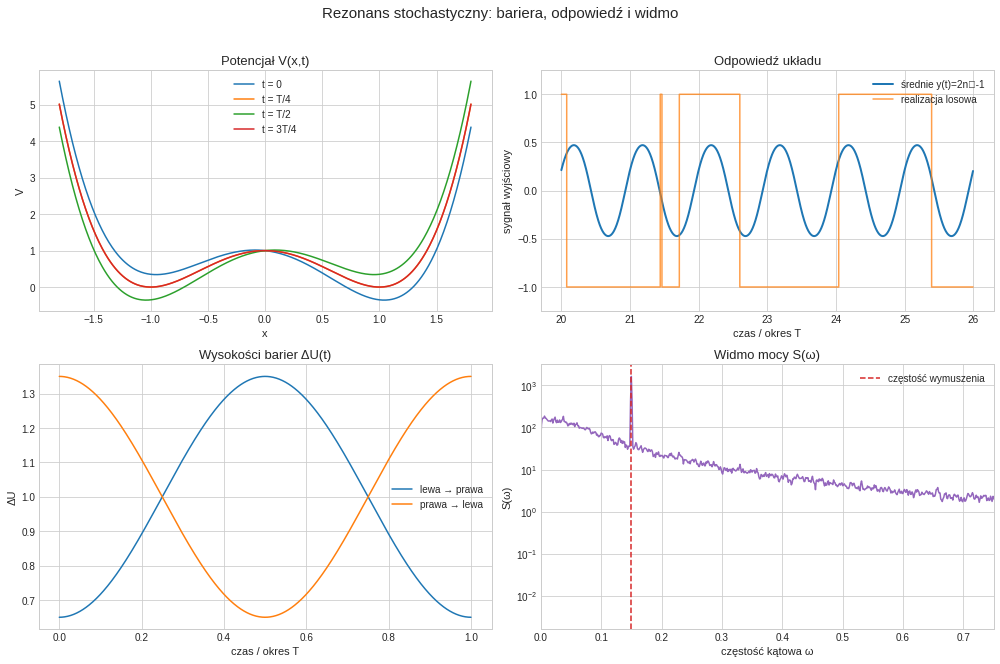

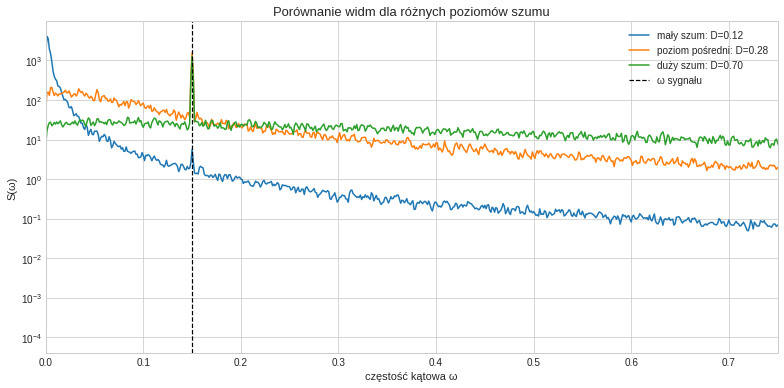

In [7]:
from dataclasses import replace

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_potential = fig.add_subplot(gs[0, 0])
ax_time = fig.add_subplot(gs[0, 1])
ax_barrier = fig.add_subplot(gs[1, 0])
ax_spectrum = fig.add_subplot(gs[1, 1])

for t_phase, label in zip(phase_times, phase_labels):
    ax_potential.plot(x, V_s(x, t_phase), label=f"t = {label}")
ax_potential.set_title("Potencjał V(x,t)")
ax_potential.set_xlabel("x")
ax_potential.set_ylabel("V")
ax_potential.legend()

ax_time.plot(t[sl] / params.period, y_mean[sl], label="średnie y(t)=2n₊-1", lw=2)
ax_time.step(t[sl] / params.period, y_sample[sl], where="post", label="realizacja losowa", alpha=0.75)
ax_time.set_title("Odpowiedź układu")
ax_time.set_xlabel("czas / okres T")
ax_time.set_ylabel("sygnał wyjściowy")
ax_time.set_ylim(-1.25, 1.25)
ax_time.legend(loc="upper right")

ax_barrier.plot(one_period / params.period, delta_lr, label="lewa → prawa")
ax_barrier.plot(one_period / params.period, delta_rl, label="prawa → lewa")
ax_barrier.set_title("Wysokości barier ΔU(t)")
ax_barrier.set_xlabel("czas / okres T")
ax_barrier.set_ylabel("ΔU")
ax_barrier.legend()

ax_spectrum.semilogy(omega_axis, spectrum_avg, color="tab:purple")
ax_spectrum.axvline(params.omega, color="tab:red", ls="--", label="częstość wymuszenia")
ax_spectrum.set_xlim(0, 5 * params.omega)
ax_spectrum.set_title("Widmo mocy S(ω)")
ax_spectrum.set_xlabel("częstość kątowa ω")
ax_spectrum.set_ylabel("S(ω)")
ax_spectrum.legend()

fig.suptitle("Rezonans stochastyczny: bariera, odpowiedź i widmo", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_figura_zbiorcza.png", dpi=180, bbox_inches="tight")
plt.show()


noise_levels = [0.12, params.D, 0.70]
noise_labels = ["mały szum", "poziom pośredni", "duży szum"]

fig, ax = plt.subplots(figsize=(11, 5.5))
for D_value, label in zip(noise_levels, noise_labels):
    p_variant = replace(params, D=D_value, seed=2026 + int(1000 * D_value))
    omega_variant, spectrum_variant, _ = averaged_spectrum(p_variant, n_realizations=45)
    ax.semilogy(omega_variant, spectrum_variant, label=f"{label}: D={D_value:.2f}")

ax.axvline(params.omega, color="black", ls="--", lw=1.2, label="ω sygnału")
ax.set_xlim(0, 5 * params.omega)
ax.set_title("Porównanie widm dla różnych poziomów szumu")
ax.set_xlabel("częstość kątowa ω")
ax.set_ylabel("S(ω)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_wplyw_poziomu_szumu.png", dpi=160)
plt.show()

## Optymalne natężenie szumu D: odpowiedź wyjściowa w dB

Ostatni slajd wykładu pokazuje ideę charakterystyki rezonansu stochastycznego: odpowiedź układu nie rośnie monotonicznie z natężeniem szumu. Dla małego `D` cząstka rzadko przekracza barierę, więc sygnał okresowy jest słabo widoczny na wyjściu. Dla zbyt dużego `D` przejścia są częste, ale chaotyczne, więc synchronizacja z wymuszeniem zanika. Między tymi skrajnościami istnieje wartość optymalna `D`, dla której składowa odpowiedzi przy częstości sygnału jest największa.

W tej sekcji dla wielu wartości `D` liczymy odpowiedź z równania Master, tworzymy sygnał `y(t)=2n_+(t)-1`, a następnie z widma mocy odczytujemy wartość przy częstości wymuszenia `ω`. Wielkość `OUTPUT(dB)` definiujemy jako moc tej składowej przeliczoną na skalę decybelową i znormalizowaną do maksimum:

$
\mathrm{OUTPUT}_{dB}(D)=10\log_{10}\left(\frac{S_D(\omega)}{\max_D S_D(\omega)}\right).
$

Dzięki normalizacji maksimum ma wartość `0 dB`, a pozostałe wartości pokazują, o ile słabsza jest odpowiedź dla danego poziomu szumu. To nie jest wykres SNR; mierzymy tylko siłę wyjściowej składowej okresowej.

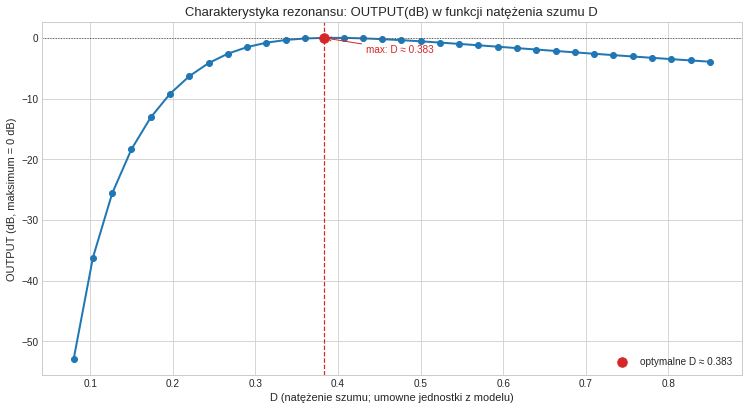

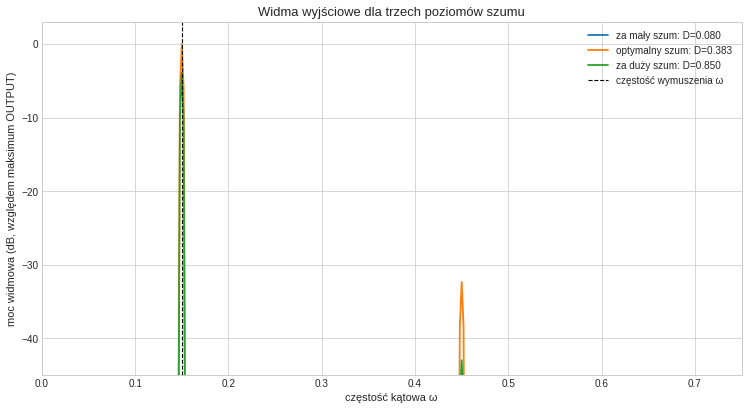

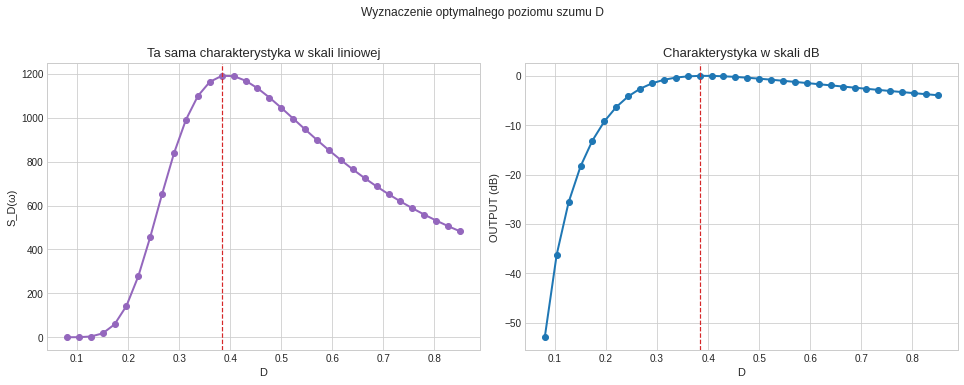

Optymalne natężenie szumu z przemiatania: D ≈ 0.383
Maksymalny OUTPUT(dB) po normalizacji: 0.0 dB


In [8]:
def output_power_at_drive_frequency(p):
    """Moc odpowiedzi przy częstości wymuszenia dla danego D."""
    t_local, n_plus_local = solve_master_equation(p)
    y_local = 2 * n_plus_local - 1
    y_stationary = y_local[p.transient_periods * p.steps_per_period :]
    omega_local, spectrum_local = power_spectrum(y_stationary, p.dt)
    drive_idx = np.argmin(np.abs(omega_local - p.omega))
    return spectrum_local[drive_idx], omega_local, spectrum_local


D_values = np.linspace(0.08, 0.85, 34)
output_powers = []
spectra_by_D = {}

sweep_params = replace(
    params,
    periods=90,
    transient_periods=15,
    steps_per_period=260,
)

for D_value in D_values:
    p_sweep = replace(sweep_params, D=float(D_value))
    power_at_drive, omega_sweep, spectrum_sweep = output_power_at_drive_frequency(p_sweep)
    output_powers.append(power_at_drive)
    spectra_by_D[float(D_value)] = (omega_sweep, spectrum_sweep)

output_powers = np.asarray(output_powers)
output_db = 10 * np.log10(output_powers / output_powers.max())
opt_idx = int(np.argmax(output_powers))
D_opt = D_values[opt_idx]
output_opt_db = output_db[opt_idx]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(D_values, output_db, marker="o", color="tab:blue", lw=2)
ax.scatter([D_opt], [output_opt_db], s=90, color="tab:red", zorder=4, label=f"optymalne D ≈ {D_opt:.3f}")
ax.axvline(D_opt, color="tab:red", ls="--", lw=1.2)
ax.axhline(0, color="0.35", ls=":", lw=1)
ax.annotate(
    f"max: D ≈ {D_opt:.3f}",
    xy=(D_opt, output_opt_db),
    xytext=(D_opt + 0.05, output_opt_db - 2.5),
    arrowprops={"arrowstyle": "->", "color": "tab:red"},
    color="tab:red",
)
ax.set_title("Charakterystyka rezonansu: OUTPUT(dB) w funkcji natężenia szumu D")
ax.set_xlabel("D (natężenie szumu; umowne jednostki z modelu)")
ax.set_ylabel("OUTPUT (dB, maksimum = 0 dB)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "07_output_db_od_D.png", dpi=170)
plt.show()

selected_indices = [0, opt_idx, len(D_values) - 1]
selected_labels = ["za mały szum", "optymalny szum", "za duży szum"]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for idx, label in zip(selected_indices, selected_labels):
    D_selected = float(D_values[idx])
    omega_selected, spectrum_selected = spectra_by_D[D_selected]
    safe_spectrum = np.maximum(spectrum_selected, 1e-300)
    normalized_spectrum_db = 10 * np.log10(safe_spectrum / output_powers.max())
    ax.plot(omega_selected, normalized_spectrum_db, lw=1.8, label=f"{label}: D={D_selected:.3f}")

ax.axvline(params.omega, color="black", ls="--", lw=1.1, label="częstość wymuszenia ω")
ax.set_xlim(0, 5 * params.omega)
ax.set_ylim(np.nanmax(output_db) - 45, 3)
ax.set_title("Widma wyjściowe dla trzech poziomów szumu")
ax.set_xlabel("częstość kątowa ω")
ax.set_ylabel("moc widmowa (dB, względem maksimum OUTPUT)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_widma_dla_roznych_D.png", dpi=170)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].plot(D_values, output_powers, marker="o", color="tab:purple", lw=2)
axes[0].axvline(D_opt, color="tab:red", ls="--", lw=1.2)
axes[0].set_title("Ta sama charakterystyka w skali liniowej")
axes[0].set_xlabel("D")
axes[0].set_ylabel("S_D(ω)")

axes[1].plot(D_values, output_db, marker="o", color="tab:blue", lw=2)
axes[1].axvline(D_opt, color="tab:red", ls="--", lw=1.2)
axes[1].set_title("Charakterystyka w skali dB")
axes[1].set_xlabel("D")
axes[1].set_ylabel("OUTPUT (dB)")

fig.suptitle("Wyznaczenie optymalnego poziomu szumu D", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_optymalne_D_podsumowanie.png", dpi=170, bbox_inches="tight")
plt.show()

print(f"Optymalne natężenie szumu z przemiatania: D ≈ {D_opt:.3f}")
print(f"Maksymalny OUTPUT(dB) po normalizacji: {output_opt_db:.1f} dB")

### Co oznacza wykres `OUTPUT(dB)`?

Ten wykres jest najkrótszym sposobem pokazania rezonansu stochastycznego. Dla każdej wartości szumu `D` sprawdzamy, jak duża część sygnału wyjściowego oscyluje z tą samą częstością co wymuszenie. Jeżeli ta składowa jest duża, układ dobrze „słyszy” słaby sygnał okresowy.

Skala decybelowa jest użyta tylko po to, żeby łatwiej porównać wartości różniące się wielokrotnie. Punkt `0 dB` oznacza najlepszy przypadek z badanego zakresu, a wartości ujemne oznaczają słabszą odpowiedź. Maksimum krzywej wskazuje optymalne `D`: taki poziom szumu, który najbardziej wzmacnia odpowiedź okresową.

To nadal nie jest klasyczny SNR, bo nie dzielimy osobno piku przez tło szumowe. W projekcie mierzymy moc odpowiedzi przy częstości wymuszenia, zgodnie z wymaganiem, że SNR nie jest potrzebny.

## Studium trzech przypadków: brak szumu, szum optymalny i szum zbyt duży

Po wyznaczeniu optymalnego poziomu szumu warto zobaczyć, jak wygląda dynamika cząstki w trzech jakościowo różnych sytuacjach.

1. **Brak szumu (`D=0`)**: słabe wymuszenie okresowe samo nie wystarcza do regularnego przekraczania bariery. Cząstka zwykle zostaje w jednej studni, a sygnał dwustanowy prawie się nie zmienia.
2. **Szum optymalny (`D≈D_opt`)**: fluktuacje są na tyle duże, żeby pomagać w przejściach wtedy, gdy wymuszenie okresowe obniża barierę. Odpowiedź dwustanowa ma wtedy największą składową przy częstości wymuszenia.
3. **Szum zbyt duży**: przejścia są bardzo częste, ale przestają być związane z fazą sygnału wejściowego. Wykres `x(t)` robi się chaotyczny, a `y(t)` przełącza się także wtedy, gdy wymuszenie nie sprzyja przejściu.

Dla każdego przypadku pokazujemy trajektorię Langevina, sygnał dwustanowy, widmo odpowiedzi oraz prostą miarę synchronizacji z wymuszeniem.

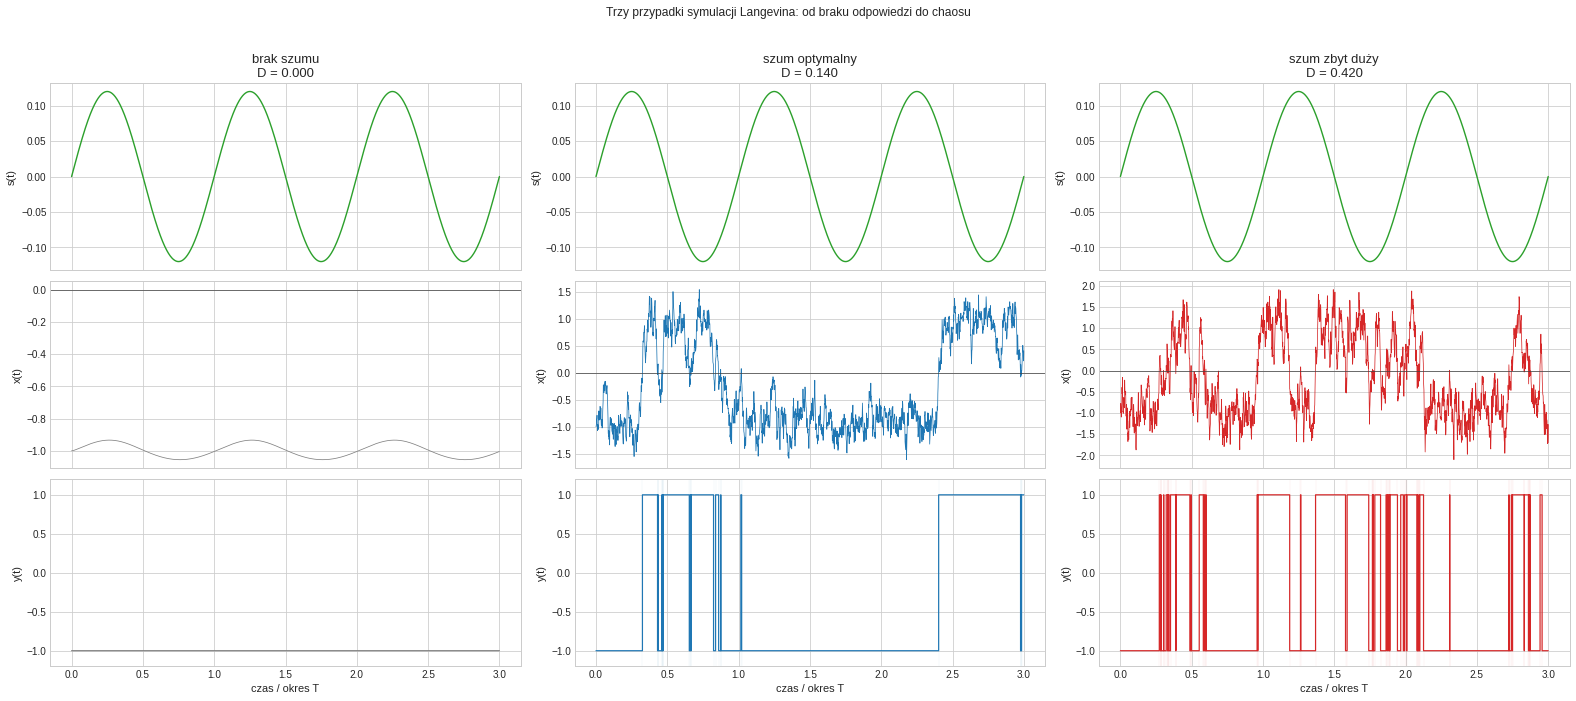

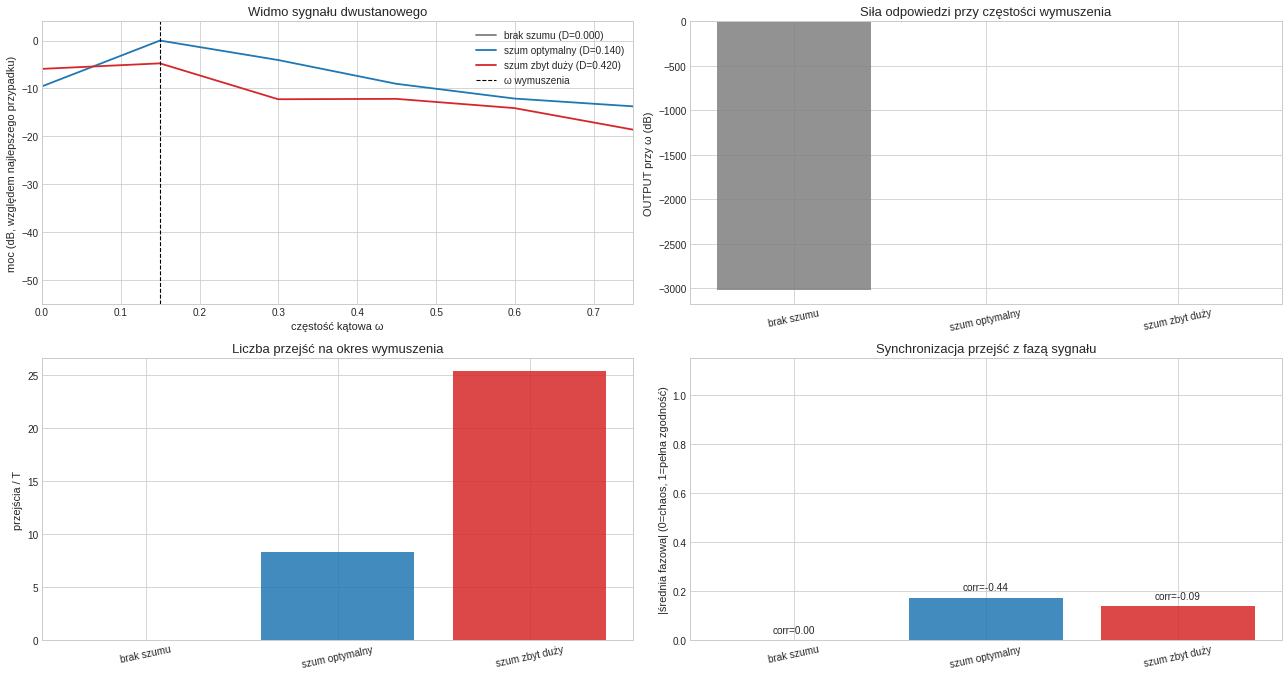

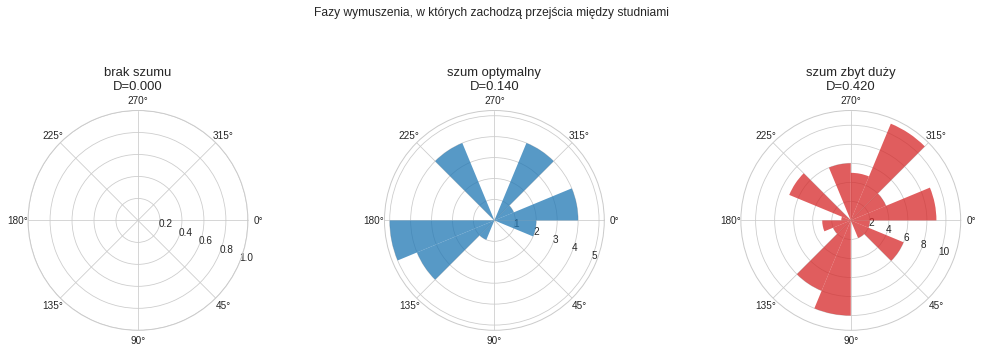

Optymalne D dla studium Langevina: 0.140
brak szumu: D=0.000, przejścia/okres=0.00, synchronizacja faz=0.00, korelacja z wymuszeniem=0.00
szum optymalny: D=0.140, przejścia/okres=8.33, synchronizacja faz=0.17, korelacja z wymuszeniem=-0.44
szum zbyt duży: D=0.420, przejścia/okres=25.33, synchronizacja faz=0.14, korelacja z wymuszeniem=-0.09


In [9]:
def langevin_output_power(noise_intensity, seed=2030, periods=18, steps_per_period=520):
    """Moc składowej dwustanowego y(t) przy częstości wymuszenia dla Langevina."""
    t_l, input_l, x_l, y_l = simulate_langevin_trajectory(
        noise_intensity=noise_intensity,
        periods=periods,
        steps_per_period=steps_per_period,
        seed=seed,
    )
    transient = 2 * steps_per_period
    omega_l, spectrum_l = power_spectrum(y_l[transient:], params.period / steps_per_period)
    drive_idx = np.argmin(np.abs(omega_l - params.omega))
    return spectrum_l[drive_idx]


langevin_D_candidates = np.linspace(0.0, 0.16, 17)
langevin_output_powers = np.array([
    langevin_output_power(D_value, seed=2030 + idx)
    for idx, D_value in enumerate(langevin_D_candidates)
])
langevin_D_opt = float(langevin_D_candidates[np.argmax(langevin_output_powers)])
D_too_large = max(0.22, 3.0 * langevin_D_opt)

case_definitions = [
    ("brak szumu", 0.0, "tab:gray"),
    ("szum optymalny", langevin_D_opt, "tab:blue"),
    ("szum zbyt duży", D_too_large, "tab:red"),
]

case_results = []
case_periods = 3
case_steps_per_period = 700

# case_periods = 24
# case_steps_per_period = 700

for idx, (label, D_case, color) in enumerate(case_definitions):
    t_case, input_case, x_case, y_case = simulate_langevin_trajectory(
        noise_intensity=D_case,
        periods=case_periods,
        steps_per_period=case_steps_per_period,
        seed=3100 + idx,
    )
    time_periods = t_case / params.period
    transition_idx = np.flatnonzero(np.diff(y_case) != 0) + 1
    transition_phases = (params.omega * t_case[transition_idx]) % (2 * np.pi)
    phase_locking = np.abs(np.mean(np.exp(1j * transition_phases))) if len(transition_phases) else 0.0
    correlation = np.corrcoef(input_case, y_case)[0, 1] if np.std(y_case) > 0 else 0.0
    omega_case, spectrum_case = power_spectrum(y_case[2 * case_steps_per_period :], params.period / case_steps_per_period)
    drive_idx = np.argmin(np.abs(omega_case - params.omega))
    output_at_drive = spectrum_case[drive_idx]
    case_results.append({
        "label": label,
        "D": D_case,
        "color": color,
        "t": t_case,
        "time_periods": time_periods,
        "input": input_case,
        "x": x_case,
        "y": y_case,
        "transition_idx": transition_idx,
        "transition_phases": transition_phases,
        "phase_locking": phase_locking,
        "correlation": correlation,
        "omega": omega_case,
        "spectrum": spectrum_case,
        "output_at_drive": output_at_drive,
        "transitions_per_period": len(transition_idx) / case_periods,
    })

fig, axes = plt.subplots(3, 3, figsize=(22, 9.5), sharex=True)
for col, result in enumerate(case_results):
    title = f"{result['label']}\nD = {result['D']:.3f}"
    axes[0, col].plot(result["time_periods"], result["input"], color="tab:green", lw=1.4)
    axes[0, col].set_title(title)
    axes[0, col].set_ylabel("s(t)")

    axes[1, col].plot(result["time_periods"], result["x"], color=result["color"], lw=0.75)
    axes[1, col].axhline(0, color="0.25", lw=0.7)
    axes[1, col].set_ylabel("x(t)")

    axes[2, col].step(result["time_periods"], result["y"], where="post", color=result["color"], lw=1.2)
    for jump_idx in result["transition_idx"]:
        axes[2, col].axvline(result["time_periods"][jump_idx], color=result["color"], lw=0.25, alpha=0.15)
    axes[2, col].set_ylabel("y(t)")
    axes[2, col].set_xlabel("czas / okres T")
    axes[2, col].set_ylim(-1.2, 1.2)

fig.suptitle("Trzy przypadki symulacji Langevina: od braku odpowiedzi do chaosu", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_trzy_przypadki_langevin.png", dpi=170, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 9.5))

for result in case_results:
    safe_spectrum = np.maximum(result["spectrum"], 1e-300)
    normalized_spectrum_db = 10 * np.log10(safe_spectrum / max(r["output_at_drive"] for r in case_results))
    axes[0, 0].plot(
        result["omega"],
        normalized_spectrum_db,
        color=result["color"],
        lw=1.8,
        label=f"{result['label']} (D={result['D']:.3f})",
    )
axes[0, 0].axvline(params.omega, color="black", ls="--", lw=1.1, label="ω wymuszenia")
axes[0, 0].set_xlim(0, 5 * params.omega)
axes[0, 0].set_ylim(-55, 4)
axes[0, 0].set_title("Widmo sygnału dwustanowego")
axes[0, 0].set_xlabel("częstość kątowa ω")
axes[0, 0].set_ylabel("moc (dB, względem najlepszego przypadku)")
axes[0, 0].legend()

labels = [result["label"] for result in case_results]
colors = [result["color"] for result in case_results]
output_values = np.array([result["output_at_drive"] for result in case_results])
output_values_db = 10 * np.log10(np.maximum(output_values, 1e-300) / output_values.max())
axes[0, 1].bar(labels, output_values_db, color=colors, alpha=0.85)
axes[0, 1].set_title("Siła odpowiedzi przy częstości wymuszenia")
axes[0, 1].set_ylabel("OUTPUT przy ω (dB)")
axes[0, 1].tick_params(axis="x", rotation=12)

transition_rates_case = [result["transitions_per_period"] for result in case_results]
axes[1, 0].bar(labels, transition_rates_case, color=colors, alpha=0.85)
axes[1, 0].set_title("Liczba przejść na okres wymuszenia")
axes[1, 0].set_ylabel("przejścia / T")
axes[1, 0].tick_params(axis="x", rotation=12)

phase_locking_values = [result["phase_locking"] for result in case_results]
axes[1, 1].bar(labels, phase_locking_values, color=colors, alpha=0.85, label="skupienie faz przejść")
for idx, result in enumerate(case_results):
    axes[1, 1].text(idx, result["phase_locking"] + 0.03, f"corr={result['correlation']:.2f}", ha="center")
axes[1, 1].set_title("Synchronizacja przejść z fazą sygnału")
axes[1, 1].set_ylabel("|średnia fazowa| (0=chaos, 1=pełna zgodność)")
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].tick_params(axis="x", rotation=12)

fig.tight_layout()
fig.savefig(FIG_DIR / "11_metryki_trzech_przypadkow.png", dpi=170)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), subplot_kw={"projection": "polar"})
for ax, result in zip(axes, case_results):
    phases = result["transition_phases"]
    if len(phases):
        bins = np.linspace(0, 2 * np.pi, 17)
        counts, edges = np.histogram(phases, bins=bins)
        widths = np.diff(edges)
        ax.bar(edges[:-1], counts, width=widths, align="edge", color=result["color"], alpha=0.75)
    ax.set_title(f"{result['label']}\nD={result['D']:.3f}")
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)

fig.suptitle("Fazy wymuszenia, w których zachodzą przejścia między studniami", y=1.08)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_fazy_przejsc_trzech_przypadkow.png", dpi=170, bbox_inches="tight")
plt.show()

print(f"Optymalne D dla studium Langevina: {langevin_D_opt:.3f}")
for result in case_results:
    print(
        f"{result['label']}: D={result['D']:.3f}, "
        f"przejścia/okres={result['transitions_per_period']:.2f}, "
        f"synchronizacja faz={result['phase_locking']:.2f}, "
        f"korelacja z wymuszeniem={result['correlation']:.2f}"
    )

### Interpretacja studium trzech przypadków

W przypadku `D=0` układ jest prawie deterministyczny: słabe wymuszenie okresowe nie daje regularnych przeskoków między studniami, więc na wyjściu brakuje wyraźnej odpowiedzi dwustanowej.

Dla szumu optymalnego przejścia pojawiają się w sposób najbardziej związany z fazą wymuszenia. W widmie rośnie składowa przy częstości `ω`, a sygnał `y(t)` najlepiej oddaje rytm sygnału wejściowego.

Dla zbyt dużego szumu liczba przejść rośnie, ale przestają one być uporządkowane. Cząstka przeskakuje między studniami także w przypadkowych momentach, dlatego odpowiedź wygląda chaotycznie: dużo aktywności nie oznacza dobrej synchronizacji.

### Jak czytać metryki w studium trzech przypadków

W studium porównujemy nie tylko kształt wykresów, ale też kilka prostych miar liczbowych:

- **Moc przy częstości wymuszenia** mówi, jak silnie w sygnale wyjściowym obecny jest rytm sygnału wejściowego. Im większa wartość, tym lepiej układ odpowiada na wymuszenie okresowe.
- **Liczba przejść na okres** pokazuje aktywność układu. Sama duża liczba przejść nie jest jeszcze dobra: przy zbyt dużym szumie przejść jest dużo, ale są przypadkowe.
- **Synchronizacja faz przejść** sprawdza, czy przejścia zachodzą w podobnej fazie sygnału wejściowego. Wartość bliska `1` oznacza uporządkowanie, a wartość bliska `0` oznacza rozrzut faz, czyli chaos.
- **Korelacja z wymuszeniem** jest pomocniczą miarą podobieństwa przebiegu `y(t)` do sygnału wejściowego.

Najważniejsza obserwacja jest jakościowa: przypadek optymalny nie musi mieć największej liczby przejść. Ma mieć przejścia wystarczająco częste i możliwie dobrze związane z okresem wymuszenia.

## Podsumowanie

Okresowe wymuszenie zmienia wysokości barier potencjału w przeciwnych fazach: gdy jedna bariera maleje, druga rośnie. Szum stochastyczny umożliwia przejścia między studniami, a dla pośredniego natężenia `D` przejścia zaczynają pojawiać się w rytmie sygnału okresowego. W odpowiedzi czasowej widać synchronizację z okresem wymuszenia, a w widmie mocy pojawia się wyraźny pik przy częstości `ω`.

Dla bardzo małego szumu układ zbyt długo pozostaje w jednej studni, więc odpowiedź na sygnał jest słaba. Dla bardzo dużego szumu przejścia są częste, ale mniej zsynchronizowane z wymuszeniem. Najbardziej czytelny rezonans stochastyczny występuje dla wartości pośredniej, gdzie szum pomaga układowi przekraczać barierę wtedy, gdy okresowa modulacja ją obniża.

W projekcie celowo nie liczono SNR, ponieważ wymagane były wizualizacja barier, wykresy czasowe i widmo mocy z pikami.